# 골반 X-ray 기반 L4 척추 분할 & 골밀도(BMD) 대리지표 측정

**파이프라인 개요**

| 단계 | 내용 | 방법 |
|------|------|------|
| 0 | DICOM 로딩 & 전처리 | `pydicom` + Modality LUT + windowing |
| 1 | L4 분할 (Segmentation) | U-Net + ResNet34 (`segmentation_models_pytorch`), Dice+BCE |
| 2 | 데이터 분할 | Train:Test = 7:3, Train 내부에서 Validation 분리 |
| 3 | 학습 / 평가 | Dice, IoU, Precision, Recall |
| 4 | BMD 대리지표 측정 | DICOM raw intensity 기반 ROI 정량 분석 + 연부조직 정규화 |
| 5 | XAI | Grad-CAM (분할 주목 영역) + ROI 기여 시각화 |

**의학적 주의:** 단순 X-ray의 픽셀강도는 정량적 BMD(g/cm²)가 **아닙니다**.
DXA가 아니므로 본 노트북은 *radiographic density proxy* (상대적 대리지표)만 산출합니다.
라벨(정상/골감소/골다공증, T-score)이 확보되면 분류기 단계를 추가해야 진단적 BMD가 가능합니다.

**경로 가정**
- 원본 DICOM: `./dataset-dcm/train/gather/`
- CVAT 마스크(VOC, L4 단일 클래스): `./dataset-dcm/train/gather_mask/`
  - `SegmentationClass/` 안에 PNG 마스크 (DICOM과 동일 파일명, 확장자만 .png)


## 0. 환경 설정 및 라이브러리

In [3]:
# !pip install albumentations

In [4]:
# 필요 시 설치 (이미 설치돼 있으면 생략)
# !pip install pydicom segmentation_models_pytorch albumentations torch torchvision scikit-image grad-cam matplotlib pandas

import os, glob, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


In [5]:
# ---- 경로 설정 ----
DICOM_DIR = Path("./dataset-dcm/train/gather/")
MASK_DIR  = Path("./dataset-dcm/train/gather_mask/SegmentationClass/")  # CVAT VOC PNG 마스크

IMG_SIZE  = 512        # 분할 입력 해상도
BATCH     = 4
EPOCHS    = 40
LR        = 1e-4


## 1. DICOM 로딩 & 전처리 유틸

DICOM은 `pydicom`으로 읽고, **Modality LUT(RescaleSlope/Intercept)**를 적용해
실제 감쇠값에 가까운 raw intensity를 얻습니다.
- 분할 입력용: 퍼센타일 windowing → [0,1] 정규화 → 3채널 복제 (ImageNet pretrained encoder용)
- BMD 측정용: **windowing 전 raw intensity**를 별도 보관 (정량 분석은 원본값으로)


In [ ]:
import pydicom
from pydicom.pixel_data_handlers.util import apply_modality_lut

def load_dicom(path):
    """ DICOM -> raw intensity(float). Modality LUT 적용, MONOCHROME1 보정."""
    ds = pydicom.dcmread(str(path))
    arr = ds.pixel_array.astype(np.float32)
    try:
        arr = apply_modality_lut(arr, ds).astype(np.float32)
    except Exception:
        slope = float(getattr(ds, "RescaleSlope", 1.0))
        inter = float(getattr(ds, "RescaleIntercept", 0.0))
        arr = arr * slope + inter
    # MONOCHROME1 이면 밝기 반전 (뼈가 밝게 보이도록 통일)
    if str(getattr(ds, "PhotometricInterpretation", "")).upper() == "MONOCHROME1":
        arr = arr.max() - arr
    return arr, ds

def window_normalize(arr, lo_p=1, hi_p=99):
    """ 퍼센타일 windowing 후 [0,1] 정규화 (분할 입력용)."""
    lo, hi = np.percentile(arr, [lo_p, hi_p])
    arr = np.clip(arr, lo, hi)
    arr = (arr - lo) / (hi - lo + 1e-8)
    return arr.astype(np.float32)


## 2. DICOM ↔ 마스크 페어링

파일명이 1:1로 매칭되므로 stem(확장자 제외) 기준으로 짝을 만듭니다.
CVAT VOC 마스크는 PNG이며, L4 픽셀은 0이 아닌 값(클래스 인덱스/색상)을 가집니다.
단일 클래스이므로 `mask > 0` 으로 이진화합니다.


In [7]:
from PIL import Image

dicom_paths = sorted([p for p in DICOM_DIR.glob("*")
                      if p.suffix.lower() in (".dcm", ".dicom", "")])
# 확장자가 없을 수도 있어 모든 파일 시도
if len(dicom_paths) == 0:
    dicom_paths = sorted(DICOM_DIR.glob("*"))

def find_mask(stem):
    for ext in (".png", ".PNG"):
        m = MASK_DIR / f"{stem}{ext}"
        if m.exists():
            return m
    return None

pairs = []
for dp in dicom_paths:
    mp = find_mask(dp.stem)
    if mp is not None:
        pairs.append((dp, mp))

print(f"총 DICOM: {len(dicom_paths)}, 마스크 매칭된 페어: {len(pairs)}")
#assert len(pairs) > 0, "매칭된 페어가 없습니다. 경로/파일명을 확인하세요."

def load_mask_binary(path, size):
    m = np.array(Image.open(path).convert("L"))
    m = (m > 0).astype(np.float32)
    m_img = Image.fromarray((m*255).astype(np.uint8)).resize((size, size), Image.NEAREST)
    return (np.array(m_img) > 127).astype(np.float32)


총 DICOM: 42, 마스크 매칭된 페어: 42


## 3. Train / Test (7:3) + Validation 분할

- 전체 → Train 70% : Test 30%
- Train 내부 → 다시 85:15 로 학습/검증 분리 (전체 기준 약 60:10:30)


In [8]:
from sklearn.model_selection import train_test_split

train_val, test = train_test_split(pairs, test_size=0.30, random_state=SEED)
train, val      = train_test_split(train_val, test_size=0.1765, random_state=SEED)  # 0.1765*0.7 ≈ 0.123

print(f"Train: {len(train)}  Val: {len(val)}  Test: {len(test)}")
print(f"비율 -> Train {len(train)/len(pairs):.0%} | Val {len(val)/len(pairs):.0%} | Test {len(test)/len(pairs):.0%}")


Train: 23  Val: 6  Test: 13
비율 -> Train 55% | Val 14% | Test 31%


## 4. Dataset & Augmentation

척추 X-ray이므로 **좌우 반전(horizontal flip)은 사용하지 않습니다** (해부학적 좌우 의미 보존). 회전·밝기·이동만 적용합니다.

In [9]:
import albumentations as A

train_aug = A.Compose([
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=10,
                       border_mode=0, p=0.5),
    A.RandomBrightnessContrast(0.15, 0.15, p=0.4),
    A.GaussNoise(p=0.2),
])

class L4Dataset(Dataset):
    def __init__(self, pairs, size=IMG_SIZE, aug=None):
        self.pairs, self.size, self.aug = pairs, size, aug
    def __len__(self): return len(self.pairs)
    def __getitem__(self, i):
        dp, mp = self.pairs[i]
        raw, _ = load_dicom(dp)
        img = window_normalize(raw)
        img_img = Image.fromarray((img*255).astype(np.uint8)).resize((self.size,self.size), Image.BILINEAR)
        img = np.array(img_img).astype(np.float32)/255.0
        mask = load_mask_binary(mp, self.size)
        if self.aug:
            out = self.aug(image=img, mask=mask)
            img, mask = out["image"], out["mask"]
        img = np.stack([img]*3, 0)                     # 3채널
        return torch.tensor(img, dtype=torch.float32), torch.tensor(mask[None], dtype=torch.float32)

train_ds = L4Dataset(train, aug=train_aug)
val_ds   = L4Dataset(val)
test_ds  = L4Dataset(test)

train_dl = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=2)
val_dl   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=2)
test_dl  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False, num_workers=2)


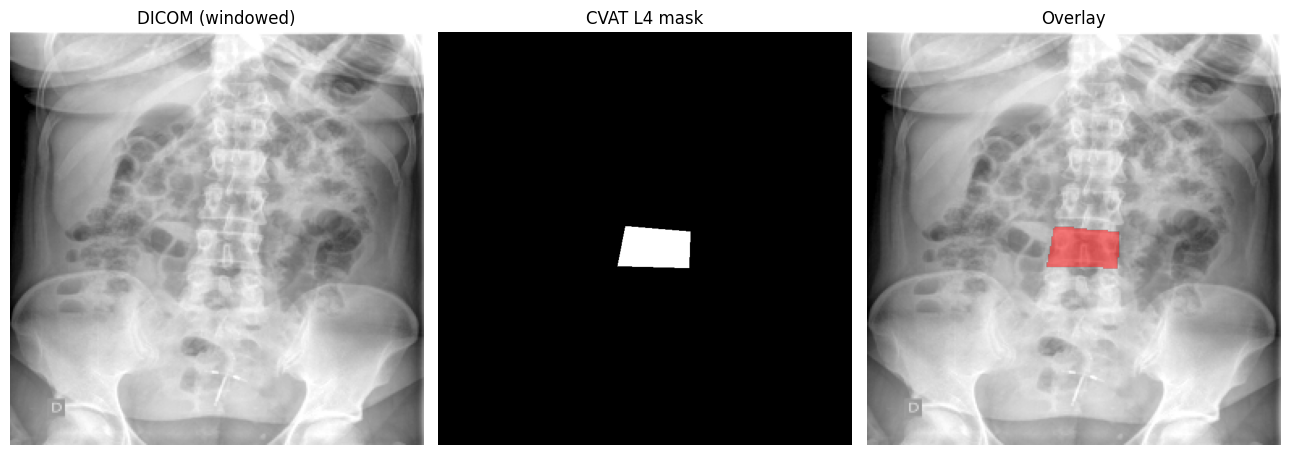

In [10]:
# 샘플 시각화: 원본 + 마스크 오버레이
dp, mp = train[0]
raw,_ = load_dicom(dp); img = window_normalize(raw)
mask = load_mask_binary(mp, img.shape[0] if img.shape[0]==img.shape[1] else IMG_SIZE)

fig, ax = plt.subplots(1,3, figsize=(13,5))
ax[0].imshow(img, cmap="gray"); ax[0].set_title("DICOM (windowed)")
mfull = np.array(Image.open(mp).convert("L"))
ax[1].imshow(mfull, cmap="gray"); ax[1].set_title("CVAT L4 mask")
ax[2].imshow(img, cmap="gray")
mover = np.array(Image.fromarray((mfull>0).astype(np.uint8)*255).resize(img.shape[::-1], Image.NEAREST))
ax[2].imshow(np.ma.masked_where(mover==0, mover), cmap="autumn", alpha=0.5)
ax[2].set_title("Overlay")
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()


## 5. 모델: U-Net + ResNet34

- **결정 근거:** 단일 클래스, 소규모 의료영상 → ImageNet pretrained encoder의 전이학습 이득이 큼.
  nnU-Net 대비 설정이 가볍고, 단순 binary 분할에 충분히 강력.
- 출력 1채널 + sigmoid, 손실 = **Dice + BCE**.


In [ ]:
import segmentation_models_pytorch as smp

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
    activation=None,            # logits 출력
).to(DEVICE)

dice_loss = smp.losses.DiceLoss(mode="binary")
bce_loss  = nn.BCEWithLogitsLoss()
def criterion(logits, target):
    return dice_loss(logits, target) + bce_loss(logits, target)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)


In [12]:
# ---- 지표 함수 ----
@torch.no_grad()
def seg_metrics(logits, target, thr=0.5):
    prob = torch.sigmoid(logits)
    pred = (prob > thr).float()
    inter = (pred*target).sum((1,2,3))
    union = pred.sum((1,2,3)) + target.sum((1,2,3))
    dice = ((2*inter+1e-6)/(union+1e-6)).mean().item()
    iou  = ((inter+1e-6)/(union-inter+1e-6)).mean().item()
    tp = inter
    prec = ((tp+1e-6)/(pred.sum((1,2,3))+1e-6)).mean().item()
    rec  = ((tp+1e-6)/(target.sum((1,2,3))+1e-6)).mean().item()
    return dice, iou, prec, rec


## 6. 학습 루프 (Validation 모니터링)

In [13]:
# 기존 num_workers=2를 0으로 변경
train_dl = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=0)
val_dl   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=0)
test_dl  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False, num_workers=0)

In [14]:
import torch

print("1. PyTorch 버전:", torch.__version__)
print("2. CUDA 사용 가능 여부:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("3. 현재 GPU 장치명:", torch.cuda.get_device_name(0))
    
    # 텐서를 하나 만들어서 GPU로 직접 올려 연산이 되는지 테스트합니다.
    try:
        x = torch.tensor([1.0, 2.0]).to("cuda")
        y = x * 2
        print("4. GPU 연산 테스트: 성공! 🎉")
    except Exception as e:
        print(f"4. GPU 연산 테스트: 실패 ❌ ({e})")

1. PyTorch 버전: 2.12.0.dev20260408+cu128
2. CUDA 사용 가능 여부: True
3. 현재 GPU 장치명: NVIDIA GeForce RTX 5060 Laptop GPU
4. GPU 연산 테스트: 성공! 🎉


In [15]:
history = {"train_loss":[], "val_loss":[], "val_dice":[], "val_iou":[]}
best_dice = 0.0
best_path = "best_l4_unet.pth"

for epoch in range(EPOCHS):
    model.train(); tloss=0
    for x,y in train_dl:
        x,y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward(); optimizer.step()
        tloss += loss.item()*x.size(0)
    tloss /= len(train_ds)

    model.eval(); vloss=0; ds=[]; ious=[]
    with torch.no_grad():
        for x,y in val_dl:
            x,y = x.to(DEVICE), y.to(DEVICE)
            out = model(x); vloss += criterion(out,y).item()*x.size(0)
            d,i,_,_ = seg_metrics(out,y); ds.append(d); ious.append(i)
    vloss/=len(val_ds); vdice=np.mean(ds); viou=np.mean(ious)
    scheduler.step()

    history["train_loss"].append(tloss); history["val_loss"].append(vloss)
    history["val_dice"].append(vdice);   history["val_iou"].append(viou)
    if vdice > best_dice:
        best_dice = vdice; torch.save(model.state_dict(), best_path)
    if epoch%2==0 or epoch==EPOCHS-1:
        print(f"E{epoch:02d} | train {tloss:.4f} | val {vloss:.4f} | dice {vdice:.4f} | iou {viou:.4f}")

print(f"Best Val Dice: {best_dice:.4f}")


E00 | train 1.9729 | val 2.9654 | dice 0.0306 | iou 0.0155
E02 | train 1.7493 | val 1.7316 | dice 0.0513 | iou 0.0264
E04 | train 1.5917 | val 1.5974 | dice 0.1043 | iou 0.0552
E06 | train 1.5251 | val 1.4411 | dice 0.2240 | iou 0.1266
E08 | train 1.4487 | val 1.3710 | dice 0.3206 | iou 0.2040
E10 | train 1.4133 | val 1.3549 | dice 0.4353 | iou 0.2989
E12 | train 1.3730 | val 1.3533 | dice 0.5492 | iou 0.4125
E14 | train 1.3498 | val 1.3090 | dice 0.5268 | iou 0.3953
E16 | train 1.3346 | val 1.2983 | dice 0.5128 | iou 0.3831
E18 | train 1.3091 | val 1.2838 | dice 0.5178 | iou 0.3808
E20 | train 1.2991 | val 1.2779 | dice 0.4894 | iou 0.3539
E22 | train 1.2906 | val 1.2750 | dice 0.5155 | iou 0.3803
E24 | train 1.2926 | val 1.2671 | dice 0.5119 | iou 0.3769
E26 | train 1.2851 | val 1.2609 | dice 0.5155 | iou 0.3798
E28 | train 1.2746 | val 1.2616 | dice 0.5258 | iou 0.3899
E30 | train 1.2708 | val 1.2567 | dice 0.5115 | iou 0.3728
E32 | train 1.2677 | val 1.2593 | dice 0.4950 | iou 0.35

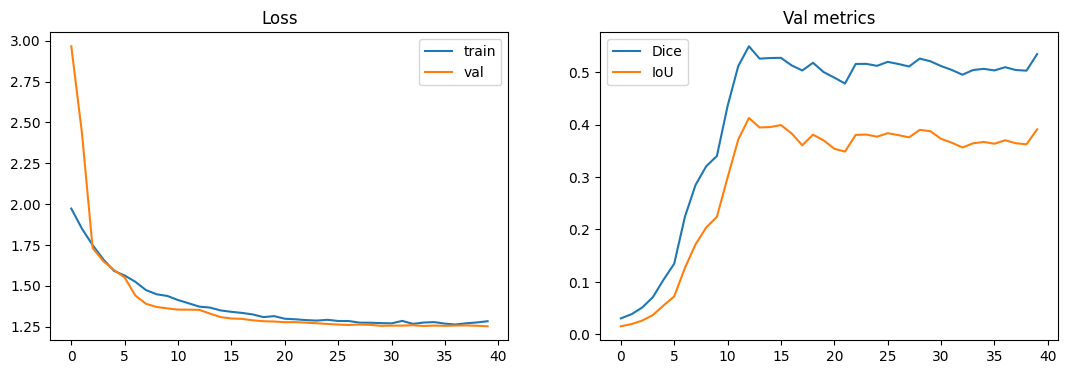

In [16]:
# 학습 곡선
fig, ax = plt.subplots(1,2, figsize=(13,4))
ax[0].plot(history["train_loss"], label="train"); ax[0].plot(history["val_loss"], label="val")
ax[0].set_title("Loss"); ax[0].legend()
ax[1].plot(history["val_dice"], label="Dice"); ax[1].plot(history["val_iou"], label="IoU")
ax[1].set_title("Val metrics"); ax[1].legend()
plt.show()


## 7. Test 평가 (7:3의 30% Hold-out)

In [17]:
model.load_state_dict(torch.load(best_path, map_location=DEVICE))
model.eval()
D=[];I=[];P=[];R=[]
with torch.no_grad():
    for x,y in test_dl:
        x,y = x.to(DEVICE), y.to(DEVICE)
        out = model(x)
        d,i,p,r = seg_metrics(out,y)
        D.append(d);I.append(i);P.append(p);R.append(r)

print("=== Test Set 결과 ===")
print(f"Dice      : {np.mean(D):.4f}")
print(f"IoU       : {np.mean(I):.4f}")
print(f"Precision : {np.mean(P):.4f}")
print(f"Recall    : {np.mean(R):.4f}")


=== Test Set 결과 ===
Dice      : 0.2931
IoU       : 0.1927
Precision : 0.2426
Recall    : 0.4373


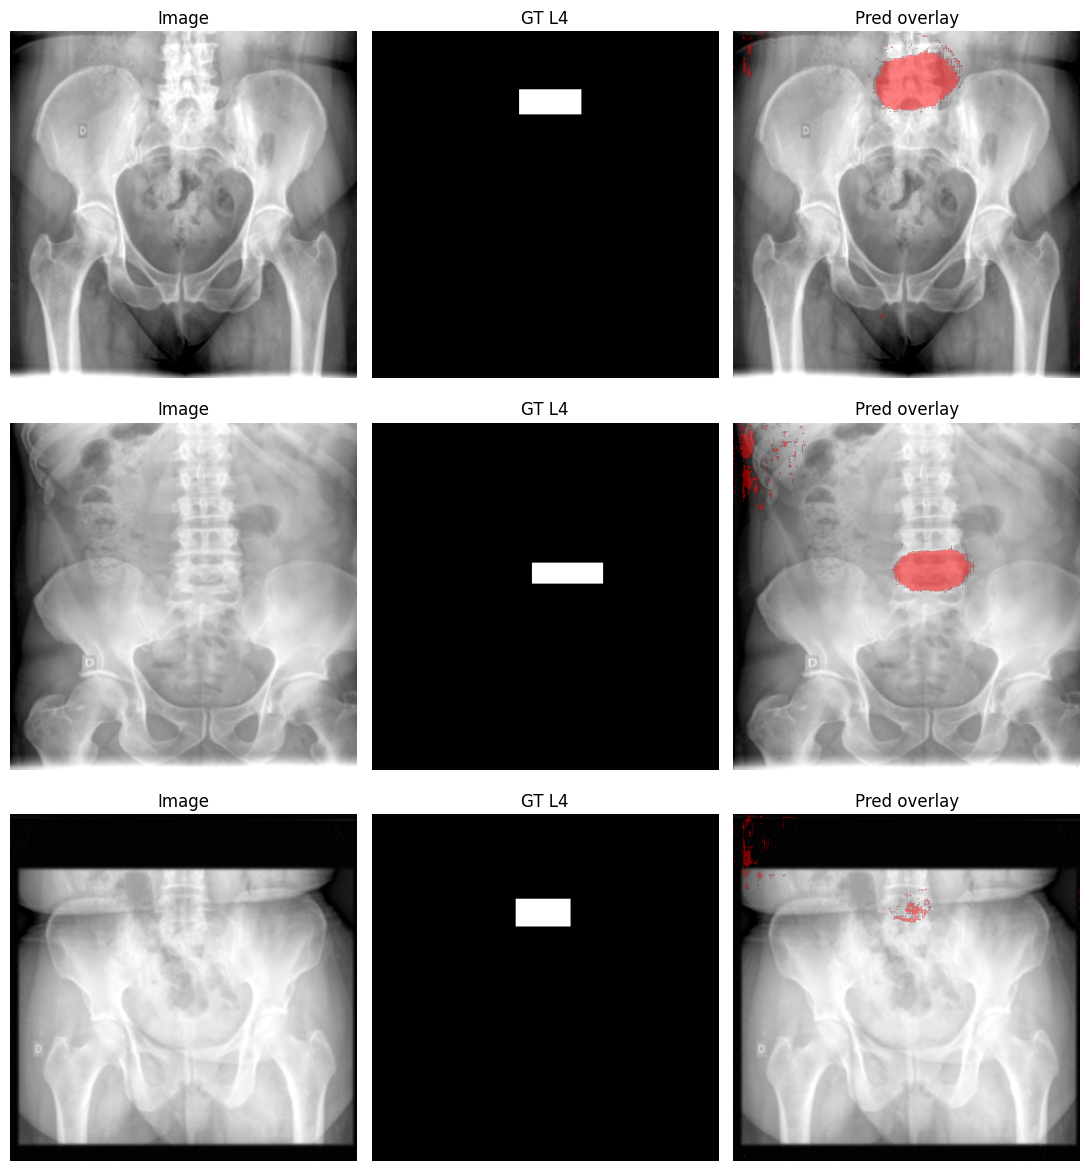

In [18]:
# 예측 시각화
x,y = next(iter(test_dl))
with torch.no_grad():
    pred = torch.sigmoid(model(x.to(DEVICE))).cpu()
n = min(3, x.size(0))
fig, ax = plt.subplots(n,3, figsize=(11,4*n))
if n==1: ax = ax[None,:]
for k in range(n):
    ax[k,0].imshow(x[k,0], cmap="gray"); ax[k,0].set_title("Image")
    ax[k,1].imshow(y[k,0], cmap="gray"); ax[k,1].set_title("GT L4")
    ax[k,2].imshow(x[k,0], cmap="gray")
    pm = (pred[k,0]>0.5).numpy()
    ax[k,2].imshow(np.ma.masked_where(~pm, pm), cmap="autumn", alpha=0.5)
    ax[k,2].set_title("Pred overlay")
    for j in range(3): ax[k,j].axis("off")
plt.tight_layout(); plt.show()


## 8. 골밀도(BMD) 대리지표 측정

분할로 얻은 L4 마스크를 **DICOM 원본 raw intensity**에 다시 투영해 정량 분석합니다.
(분할은 512 해상도에서 했지만, 측정은 원본 해상도 raw값에서 수행)

**측정 지표**
1. ROI 평균/중앙값 intensity
2. **연부조직 정규화 비율** — L4 주변 연부조직(배경) 대비 ROI 강도비
   → 환자별 노출량/장비 차이 보정 (대리지표의 핵심)
3. 골소주 텍스처 (GLCM contrast, homogeneity, entropy) — 골다공증 시 골소주 소실 반영
4. 강도 표준편차 / 히스토그램 통계

낮은 정규화 강도 + 낮은 텍스처 대비 = 골밀도 저하 경향 (상대 비교용).


In [20]:
from skimage.feature import graycomatrix, graycoprops
from scipy import ndimage

@torch.no_grad()
def predict_full_mask(dicom_path, thr=0.5):
    raw, ds = load_dicom(dicom_path)
    img = window_normalize(raw)
    H,W = raw.shape
    img_r = np.array(Image.fromarray((img*255).astype(np.uint8))
                     .resize((IMG_SIZE,IMG_SIZE), Image.BILINEAR)).astype(np.float32)/255.0
    t = torch.tensor(np.stack([img_r]*3,0)[None], dtype=torch.float32, device=DEVICE)
    prob = torch.sigmoid(model(t))[0,0].cpu().numpy()
    mask_full = np.array(Image.fromarray((prob>thr).astype(np.uint8)*255)
                         .resize((W,H), Image.NEAREST)) > 127
    return raw, mask_full

def soft_tissue_ring(mask, dist=40):
    """ROI 바깥 연부조직 링(배경 보정용)."""
    dil = ndimage.binary_dilation(mask, iterations=dist)
    ring = dil & ~ndimage.binary_dilation(mask, iterations=8)
    return ring

def bmd_proxy(dicom_path):
    raw, mask = predict_full_mask(dicom_path)
    if mask.sum() < 50:
        return None
    roi_vals = raw[mask]
    ring = soft_tissue_ring(mask)
    bg_vals = raw[ring] if ring.sum()>50 else raw[~mask]

    roi_mean = float(roi_vals.mean()); roi_med = float(np.median(roi_vals))
    bg_mean  = float(bg_vals.mean())
    norm_ratio = roi_mean / (bg_mean + 1e-6)     # 연부조직 정규화 강도

    # GLCM 텍스처 (ROI bounding box, 8bit 양자화)
    ys,xs = np.where(mask); y0,y1,x0,x1 = ys.min(),ys.max(),xs.min(),xs.max()
    patch = raw[y0:y1+1, x0:x1+1].copy()
    pm = mask[y0:y1+1, x0:x1+1]
    p = patch.copy()
    lo,hi = np.percentile(patch[pm], [1,99]); p = np.clip(p,lo,hi)
    p = ((p-lo)/(hi-lo+1e-8)*255).astype(np.uint8); p[~pm]=0
    glcm = graycomatrix(p, [1], [0, np.pi/2], levels=256, symmetric=True, normed=True)
    contrast = float(graycoprops(glcm,"contrast").mean())
    homog    = float(graycoprops(glcm,"homogeneity").mean())
    energy   = float(graycoprops(glcm,"energy").mean())

    return dict(file=Path(dicom_path).stem,
                roi_mean=roi_mean, roi_median=roi_med,
                bg_mean=bg_mean, norm_ratio=norm_ratio,
                roi_std=float(roi_vals.std()),
                glcm_contrast=contrast, glcm_homogeneity=homog, glcm_energy=energy,
                area_px=int(mask.sum()))


In [21]:
# Test 세트 전체에 대해 BMD 대리지표 산출
records = []
for dp,_ in test:
    r = bmd_proxy(dp)
    if r: records.append(r)
bmd_df = pd.DataFrame(records)
bmd_df.head(10)


,file,roi_mean,roi_median,bg_mean,norm_ratio,roi_std,glcm_contrast,glcm_homogeneity,glcm_energy,area_px
0,1.2.826.0.1.3680043.8.498.59513984062726763251...,13180.625977,13880.0,10496.148438,1.255758,2271.612793,133.907159,0.967309,0.962253,2287
1,1.2.826.0.1.3680043.8.498.16025804384837533255...,9919.174805,11531.5,9971.346680,0.994768,3688.903320,167.680916,0.970828,0.965281,1982
2,1.2.826.0.1.3680043.8.498.12209232711532162247...,5714.926270,1895.0,7320.493164,0.780675,4566.849121,119.861970,0.991579,0.990251,449
3,1.2.826.0.1.3680043.8.498.59790473896195535824...,10588.703125,11173.0,10427.397461,1.015469,2990.778076,315.729100,0.955174,0.947295,2092
4,1.2.826.0.1.3680043.8.498.11227155170490832168...,12603.139648,12863.0,10194.732422,1.236240,1283.007690,126.089552,0.988097,0.986755,761
5,1.2.826.0.1.3680043.8.498.94781665980010195027...,11639.410156,12004.0,8204.624023,1.418640,1535.552368,172.700826,0.979965,0.976742,1377
6,1.2.826.0.1.3680043.8.498.45236243316424404018...,10986.196289,11030.0,9526.961914,1.153169,1719.979370,165.278532,0.973703,0.970102,1772
7,1.2.826.0.1.3680043.8.498.69984126810063910029...,10326.681641,11414.0,10214.150391,1.011017,2691.178467,289.491254,0.969975,0.966420,1860
8,1.2.826.0.1.3680043.8.498.79026492809342944566...,2240.026855,1591.0,6720.479980,0.333314,2274.545654,32.498934,0.991450,0.989826,373
9,1.2.826.0.1.3680043.8.498.11479964994316715381...,11767.008789,12202.0,10419.081055,1.129371,2245.218262,366.292278,0.972111,0.967190,1872


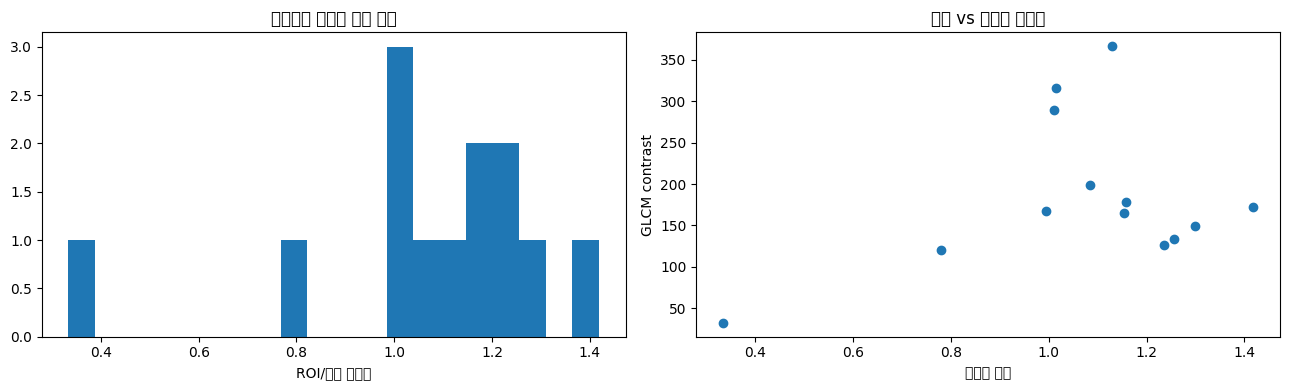

하위 5건 (골밀도 저하 경향, 상대 비교):


'                                                              file  norm_ratio  glcm_contrast  bmd_proxy_score\n1.2.826.0.1.3680043.8.498.79026492809342944566348448622650687119-c    0.333314      32.498934        -2.390322\n1.2.826.0.1.3680043.8.498.12209232711532162247608981043714969492-c    0.780675     119.861970        -0.961221\n1.2.826.0.1.3680043.8.498.16025804384837533255224060211228287365-c    0.994768     167.680916        -0.249440\n1.2.826.0.1.3680043.8.498.13143567732829440604976762413697359542-c    1.083619     199.200347         0.100076\n1.2.826.0.1.3680043.8.498.45236243316424404018779373210543092610-c    1.153169     165.278532         0.102038'

In [22]:
# 대리지표 종합 점수 (z-score 결합): 높을수록 골밀도 양호 경향
from scipy.stats import zscore
df = bmd_df.copy()
df["z_density"] = zscore(df["norm_ratio"])
df["z_texture"] = zscore(df["glcm_contrast"])   # 골소주 대비 ↑ = 골질 양호 경향
df["bmd_proxy_score"] = df["z_density"]*0.6 + df["z_texture"]*0.4
df = df.sort_values("bmd_proxy_score")

fig, ax = plt.subplots(1,2, figsize=(13,4))
ax[0].hist(df["norm_ratio"], bins=20); ax[0].set_title("연부조직 정규화 강도 분포")
ax[0].set_xlabel("ROI/배경 강도비")
ax[1].scatter(df["norm_ratio"], df["glcm_contrast"])
ax[1].set_xlabel("정규화 강도"); ax[1].set_ylabel("GLCM contrast")
ax[1].set_title("강도 vs 골소주 텍스처")
plt.tight_layout(); plt.show()

print("하위 5건 (골밀도 저하 경향, 상대 비교):")
df[["file","norm_ratio","glcm_contrast","bmd_proxy_score"]].head().to_string(index=False)


## 9. XAI — Grad-CAM (분할 모델 설명)

분할 모델이 **어느 영역을 보고 L4로 판단했는지** Grad-CAM으로 시각화합니다.
encoder의 마지막 stage feature를 타깃으로 합니다.


In [26]:
#! pip install "grad-cam"

     ---------------------------------------- 0.0/7.8 MB ? eta -:--:--
     ------------ --------------------------- 2.4/7.8 MB 22.3 MB/s eta 0:00:01
     ---------------------------------------- 7.8/7.8 MB 30.1 MB/s  0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44340 sha256=3d36b47a25c96513a8c16a3ea656fe074297a05ee1d65b370b10f0feed6ecf10
  Stored in directory: c:\users\csm02\appdata\local\pip\cache\wheels\fb\3b\09\2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam

   -------------------- ------------------- 1/2 [grad-cam]
   -------------------- ------------------- 1/2 [grad-cam]
   -----------

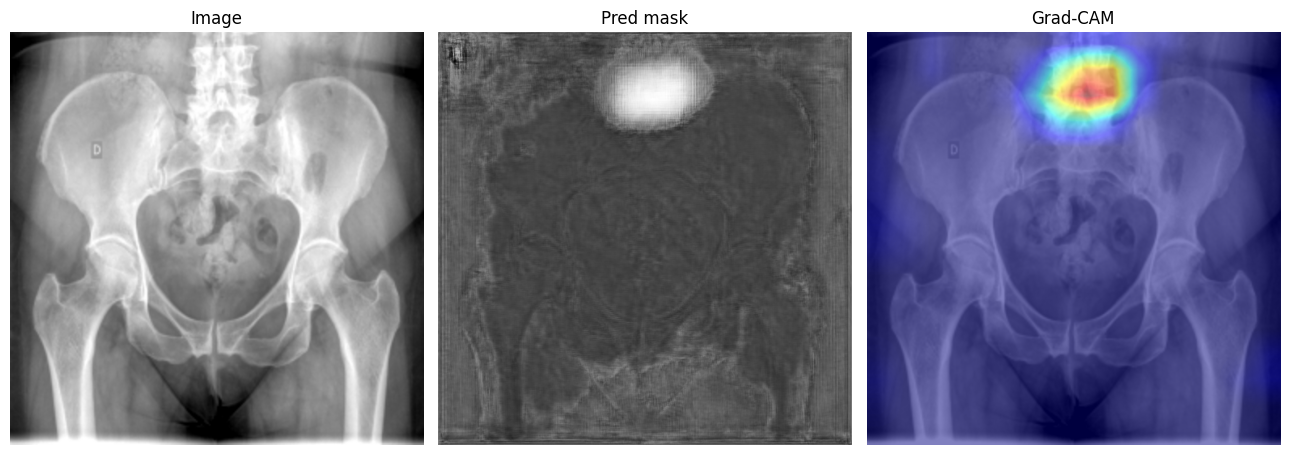

In [27]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import SemanticSegmentationTarget

# encoder 마지막 블록을 타깃 레이어로
target_layers = [model.encoder.layer4[-1]]

x,y = next(iter(test_dl))
input_tensor = x[:1].to(DEVICE)
with torch.no_grad():
    out = torch.sigmoid(model(input_tensor))[0,0].cpu().numpy()
mask_float = (out>0.5).astype(np.float32)

cam = GradCAM(model=model, target_layers=target_layers)
targets = [SemanticSegmentationTarget(0, mask_float)]
grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]

fig, ax = plt.subplots(1,3, figsize=(13,5))
ax[0].imshow(x[0,0], cmap="gray"); ax[0].set_title("Image")
ax[1].imshow(out, cmap="gray"); ax[1].set_title("Pred mask")
ax[2].imshow(x[0,0], cmap="gray")
ax[2].imshow(grayscale_cam, cmap="jet", alpha=0.5)
ax[2].set_title("Grad-CAM")
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()


### 9-2. BMD 대리지표 설명 (ROI intensity 히트맵)

분류 모델이 아니므로 SHAP 대신, 측정의 근거가 되는 **ROI 내부 강도 분포**를
직접 히트맵으로 보여 어느 부위가 점수에 기여했는지 설명합니다.


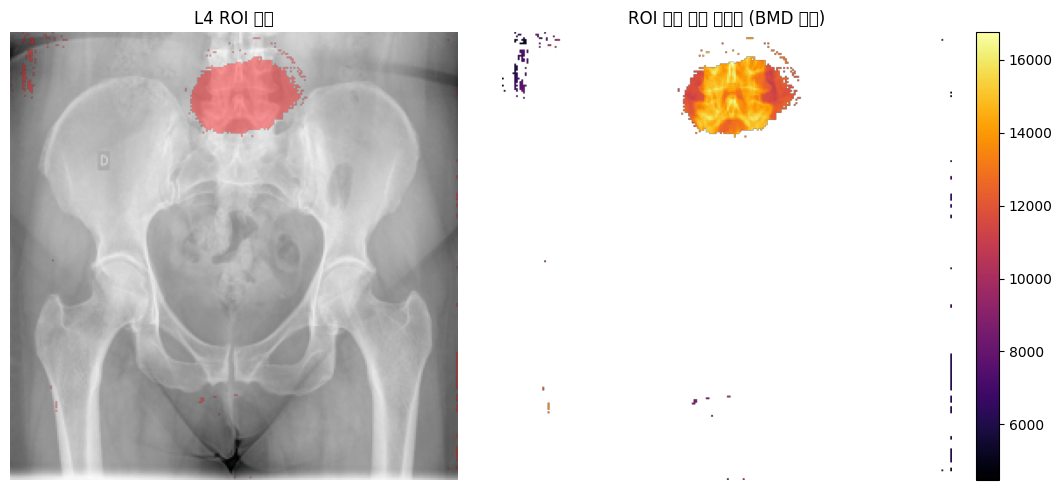

In [28]:
dp = test[0][0]
raw, mask = predict_full_mask(dp)
ys,xs = np.where(mask); y0,y1,x0,x1 = ys.min(),ys.max(),xs.min(),xs.max()
patch = raw[y0:y1+1, x0:x1+1].copy().astype(np.float32)
pm = mask[y0:y1+1, x0:x1+1]
patch[~pm] = np.nan

fig, ax = plt.subplots(1,2, figsize=(11,5))
ax[0].imshow(raw, cmap="gray")
ax[0].imshow(np.ma.masked_where(~mask, mask), cmap="autumn", alpha=0.4)
ax[0].set_title("L4 ROI 위치"); ax[0].axis("off")
im = ax[1].imshow(patch, cmap="inferno")
ax[1].set_title("ROI 내부 강도 히트맵 (BMD 기여)"); ax[1].axis("off")
plt.colorbar(im, ax=ax[1], fraction=0.046)
plt.tight_layout(); plt.show()


## 10. 결론 및 한계

**구현 요약**
- L4 단일 클래스 분할: U-Net+ResNet34, Dice+BCE, Train:Val:Test ≈ 60:10:30 (7:3 기반)
- 평가: Dice / IoU / Precision / Recall
- BMD: 분류 라벨이 없어 **radiographic density proxy** (연부조직 정규화 강도 + GLCM 텍스처)
- XAI: Grad-CAM(분할) + ROI 강도 히트맵(측정 근거)

**한계 (중요)**
1. 단순 X-ray 픽셀강도는 정량 BMD(g/cm²)가 아님 → 본 지표는 *상대 비교용*.
2. 환자 간 노출·장비 차이를 연부조직 정규화로 보정했으나 완전하지 않음.
3. 진단적 BMD가 목표라면 **DXA 라벨 또는 정상/골감소/골다공증 라벨**을 확보해
   분할 ROI → DenseNet-121 분류 + WHO T-score 매핑 단계를 추가해야 함.

**다음 단계 제안**
- 라벨 확보 시 2단계 분류기 추가
- phantom(보정용 알루미늄 계단 쐐기)이 촬영에 포함되면 진짜 정량 보정 가능
